ACROSS-PARTICIPANT RSA

ISPC: correlates each participant's voxel pattern for each event with the group mean pattern for that event (excluding themselves)
separately for vice, virtue and non-moral sentences
average across left and right hemisphere
paired t test


In [1]:
import os
import numpy as np
from nilearn import image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, zscore, ttest_rel, pearsonr, ttest_ind
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, ttest_1samp
import seaborn as sns
from scipy.stats import sem
from scipy.signal import detrend
import pingouin as pg
from statsmodels.stats.multitest import multipletests

In [2]:
foundationScores_dir = "/Users/silvycollin/Documents/GitHub/wholeBrain_narratives_MAC_MFT/text/foundationScores/"

In [3]:
whichVersion = 'persentence' #persentence, 3sec, 6sec

whichROI = "TPJ_refined_mask" # hippocampus,TPJ_refined_mask,STG_MTG_refined_mask

whichStory = "tunnel"  # tunnel, 21styear, shapessocial, shapesphysical, prettymouthparanoia,prettymouthaffair


In [4]:
# save
save_dir = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/RSA/"
)


In [5]:
# ------------------------
# Load 
# ------------------------


base_dir = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_first_level_per_sentence/"
)


if whichVersion =='persentence':
    foundationScores_file = f"{foundationScores_dir}{whichStory}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
elif whichVersion =='3sec':
    foundationScores_file = f"{foundationScores_dir}{whichStory}_3_seconds_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
elif whichVersion =='6sec':
    foundationScores_file = f"{foundationScores_dir}{whichStory}_6_seconds_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)

print(whichStory)
print(whichROI)

data_dir = f"{base_dir}{whichStory}/"


left = np.load(data_dir + f"{whichStory}_{whichROI}_L_3D_clean.npy")
right = np.load(data_dir + f"{whichStory}_{whichROI}_R_3D_clean.npy")

tunnel
TPJ_refined_mask


In [6]:
# List columns
virtue_cols = [
    "MAC_a_fairness_virtue", "MAC_a_group_virtue", "MAC_a_deference_virtue",
    "MAC_a_heroism_virtue", "MAC_a_reciprocity_virtue",
    "MAC_a_family_virtue", "MAC_a_property_virtue"
]

vice_cols = [
    "MAC_a_fairness_vice", "MAC_a_group_vice", "MAC_a_deference_vice",
    "MAC_a_heroism_vice", "MAC_a_reciprocity_vice",
    "MAC_a_family_vice", "MAC_a_property_vice"
]

all_cols = virtue_cols + vice_cols

# 1. --- NON-MORAL: all 14 columns are zero ---
nonmoral_df = foundationScores[foundationScores[all_cols].sum(axis=1) == 0]

# Filter out nonmoral rows to classify the rest
moral_df = foundationScores[foundationScores[all_cols].sum(axis=1) != 0].copy()

# Find the column with the highest value per row
moral_df["max_col"] = moral_df[all_cols].idxmax(axis=1)

# 2. --- VICE: max column is a vice column ---
vice_df = moral_df[moral_df["max_col"].isin(vice_cols)].drop(columns=["max_col"])

# 3. --- VIRTUE: max column is a virtue column ---
virtue_df = moral_df[moral_df["max_col"].isin(virtue_cols)].drop(columns=["max_col"])


In [7]:
# ------------------------
# load foundation scores 
# ------------------------
# start and end column is start and end of the sentences in seconds, TR was 1.5 sec
nonmoral_df = nonmoral_df[["start","end"]]
nonmoral_df = nonmoral_df.copy()

vice_df = vice_df[["start","end"]]
vice_df = vice_df.copy()

virtue_df = virtue_df[["start","end"]]
virtue_df = virtue_df.copy()

# go from seconds to TRs for start and end column
nonmoral_df["startTR"] = nonmoral_df["start"] / 1.5
nonmoral_df["endTR"] = nonmoral_df["end"] / 1.5

vice_df["startTR"] = vice_df["start"] / 1.5
vice_df["endTR"] = vice_df["end"] / 1.5

virtue_df["startTR"] = virtue_df["start"] / 1.5
virtue_df["endTR"] = virtue_df["end"] / 1.5

# round to full TRs/volumes
nonmoral_df["startTR"] = nonmoral_df["startTR"].round(0).astype(int)
nonmoral_df["endTR"] = nonmoral_df["endTR"].round(0).astype(int)

vice_df["startTR"] = vice_df["startTR"].round(0).astype(int)
vice_df["endTR"] = vice_df["endTR"].round(0).astype(int)

virtue_df["startTR"] = virtue_df["startTR"].round(0).astype(int)
virtue_df["endTR"] = virtue_df["endTR"].round(0).astype(int)

# shift by 3 TRs for the HRF
nonmoral_df['startTR'] = nonmoral_df['startTR'] + 3
nonmoral_df['endTR'] = nonmoral_df['endTR'] + 3

vice_df['startTR'] = vice_df['startTR'] + 3
vice_df['endTR'] = vice_df['endTR'] + 3

virtue_df['startTR'] = virtue_df['startTR'] + 3
virtue_df['endTR'] = virtue_df['endTR'] + 3


In [8]:
def compute_event_patterns(data_array, events_df):
    """
    Returns event-averaged spatial patterns for each participant.
    Output shape: (voxels, n_events, n_participants)
    """
    events_df = events_df.dropna(subset=['startTR', 'endTR']).sort_values("startTR").reset_index(drop=True)
    n_vox, n_tr, n_part = data_array.shape
    n_events = len(events_df)

    # Z-score each participant
    data_z = np.zeros_like(data_array)
    for p in range(n_part):
        data_z[:, :, p] = zscore(data_array[:, :, p], axis=1, ddof=1)

    # Compute event patterns = mean activity in event window
    event_patterns = np.zeros((n_vox, n_events, n_part))
    for i, ev in events_df.iterrows():
        startTR, endTR = int(ev.startTR), int(ev.endTR)
        event_patterns[:, i, :] = np.mean(data_z[:, startTR:endTR+1, :], axis=1)

    return event_patterns

def make_group_template(event_patterns, exclude_participant=None, exclude_event=None):
    """
    event_patterns: shape (voxels, events, participants)
    exclude_participant: index or None
    exclude_event: index or None
    """

    n_vox, n_events, n_part = event_patterns.shape

    mask_part = np.ones(n_part, dtype=bool)
    mask_event = np.ones(n_events, dtype=bool)

    if exclude_participant is not None:
        mask_part[exclude_participant] = False

    if exclude_event is not None:
        # only exclude valid event indices
        if 0 <= exclude_event < n_events:
            mask_event[exclude_event] = False

    # select
    valid = event_patterns[:, mask_event][:, :, mask_part]
    valid = valid.reshape(n_vox, -1)

    return valid.mean(axis=1)


def run_template_matching(data_array, df_vice, df_virtue, df_nonmoral):

    patt_vice = compute_event_patterns(data_array, df_vice)
    patt_virtue = compute_event_patterns(data_array, df_virtue)
    patt_nonmoral = compute_event_patterns(data_array, df_nonmoral)

    categories = {
        "vice": patt_vice,
        "virtue": patt_virtue,
        "nonmoral": patt_nonmoral,
    }

    results = {}

    for cat, patt_cat in categories.items():

        n_vox, n_events_cat, n_part = patt_cat.shape
        out = np.zeros((n_events_cat, n_part, 3))

        for p in range(n_part):
            for e in range(n_events_cat):

                this_pattern = patt_cat[:, e, p]

                # category-specific leave-event-out
                grp_same = make_group_template(
                    patt_cat,
                    exclude_participant=p,
                    exclude_event=e
                )

                # other categories: leave-participant-out only
                grp_other1 = make_group_template(
                    categories["vice"],
                    exclude_participant=p if cat == "vice" else p,
                    exclude_event=e if cat == "vice" else None
                )

                grp_other2 = make_group_template(
                    categories["virtue"],
                    exclude_participant=p if cat == "virtue" else p,
                    exclude_event=e if cat == "virtue" else None
                )

                grp_other3 = make_group_template(
                    categories["nonmoral"],
                    exclude_participant=p if cat == "nonmoral" else p,
                    exclude_event=e if cat == "nonmoral" else None
                )

                # always order: vice, virtue, nonmoral
                out[e, p, 0] = pearsonr(this_pattern, grp_other1)[0]
                out[e, p, 1] = pearsonr(this_pattern, grp_other2)[0]
                out[e, p, 2] = pearsonr(this_pattern, grp_other3)[0]

        results[cat] = out

    return results


print("Running TEMPLATE MATCHING for LEFT hemisphere...")
results_left = run_template_matching(left, vice_df, virtue_df, nonmoral_df)

print("Running TEMPLATE MATCHING for RIGHT hemisphere...")
results_right = run_template_matching(right, vice_df, virtue_df, nonmoral_df)

Running TEMPLATE MATCHING for LEFT hemisphere...
Running TEMPLATE MATCHING for RIGHT hemisphere...


In [9]:
def sanity_check(results, df_vice, df_virtue, df_nonmoral, hemisphere="LEFT"):
    print(f"\n===== SANITY CHECK — {hemisphere} hemisphere =====")

    print("\nEvent counts from dataframes:")
    print(f"  Vice events:     {len(df_vice)}")
    print(f"  Virtue events:   {len(df_virtue)}")
    print(f"  Nonmoral events: {len(df_nonmoral)}")

    print("\nTemplate result shapes (events × participants × templates):")
    for key in ["vice", "virtue", "nonmoral"]:
        arr = results[key]
        print(f"  {key}: {arr.shape}")

    # check consistent participant count
    parts = {results[key].shape[1] for key in results}
    if len(parts) != 1:
        print("\n❌ WARNING: participant counts differ across categories:", parts)
    else:
        print("\n✔ Participant count is consistent:", parts.pop())

    # check template dimension always 3
    temps = {results[key].shape[2] for key in results}
    if temps != {3}:
        print("\n❌ ERROR: template dimension is wrong:", temps)
    else:
        print("\n✔ Template dimension OK (3 templates)")

    print("===== END SANITY CHECK =====\n")

sanity_check(results_left, vice_df, virtue_df, nonmoral_df, "LEFT")
sanity_check(results_right, vice_df, virtue_df, nonmoral_df, "RIGHT")



===== SANITY CHECK — LEFT hemisphere =====

Event counts from dataframes:
  Vice events:     172
  Virtue events:   145
  Nonmoral events: 231

Template result shapes (events × participants × templates):
  vice: (172, 21, 3)
  virtue: (145, 21, 3)
  nonmoral: (231, 21, 3)

✔ Participant count is consistent: 21

✔ Template dimension OK (3 templates)
===== END SANITY CHECK =====


===== SANITY CHECK — RIGHT hemisphere =====

Event counts from dataframes:
  Vice events:     172
  Virtue events:   145
  Nonmoral events: 231

Template result shapes (events × participants × templates):
  vice: (172, 21, 3)
  virtue: (145, 21, 3)
  nonmoral: (231, 21, 3)

✔ Participant count is consistent: 21

✔ Template dimension OK (3 templates)
===== END SANITY CHECK =====



In [10]:
def summarize_template_corr(results_cat):
    """
    results_cat: array (n_events × n_participants × 3 templates)
    Returns arrays for:
       corr_with_vice_template,
       corr_with_virtue_template,
       corr_with_nonmoral_template
    (each size = n_participants)
    """
    mean_events = results_cat.mean(axis=0)  # participants × 3
    return mean_events[:, 0], mean_events[:, 1], mean_events[:, 2]


In [11]:

def compute_stats_for_triplet(values_v, values_u, values_n,
                              event_category):
    """
    For a given event category (e.g. 'vice events')
    compute:
    - one-sample t-test for each template
    - pairwise t-tests between templates
    Returns a DataFrame.
    """

    templates = {
        "Vice template": values_v,
        "Virtue template": values_u,
        "Nonmoral template": values_n
    }

    rows = []

    # ----------------------
    # 1) One-sample tests
    # ----------------------
    for name, vals in templates.items():
        t, p = ttest_1samp(vals, 0)
        rows.append({
            "Event Category": event_category,
            "Template Category": name,
            "Comparison": "vs 0",
            "Mean": np.mean(vals),
            "SEM": np.std(vals) / np.sqrt(len(vals)),
            "t": t,
            "p": p
        })

    # ----------------------
    # 2) Pairwise comparisons (within participants)
    # ----------------------
    pairs = [
        ("Vice template", "Virtue template"),
        ("Vice template", "Nonmoral template"),
        ("Virtue template", "Nonmoral template"),
    ]

    for a, b in pairs:
        t, p = ttest_rel(templates[a], templates[b])
        rows.append({
            "Event Category": event_category,
            "Template Category": f"{a} vs {b}",
            "Comparison": "Paired t-test",
            "Mean": np.mean(templates[a] - templates[b]),
            "SEM": np.std(templates[a] - templates[b]) / np.sqrt(len(vals)),
            "t": t,
            "p": p
        })

    return pd.DataFrame(rows)

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "n.s."


In [12]:
def plot_condensed_4bar(results, hemisphere_label="LEFT"):
    """
    results[event] shape: (n_events, n_participants, 3)
    template index: 0 = vice, 1 = virtue, 2 = non-moral

    This version keeps only:
      - Vice -> Vice
      - Vice -> Virtue
      - Virtue -> Vice
      - Virtue -> Virtue
    """

    import numpy as np
    import matplotlib.pyplot as plt

    # Only 4 conditions
    keys = [
        ("vice",   0),   # Vice event → Vice template
        ("vice",   1),   # Vice event → Virtue template
        ("virtue", 0),   # Virtue event → Vice template
        ("virtue", 1),   # Virtue event → Virtue template
    ]

    labels = ["Vice→Vice", "Vice→Virtue", "Virtue→Vice", "Virtue→Virtue"]

    color_map = {
        "vice":   "#8E44AD",
        "virtue": "#3498DB"
    }

    means = []
    sems = []
    colors = []
    participant_values_list = []

    # Process each of the 4 conditions
    for ev, tmpl_idx in keys:
        data = results[ev][:, :, tmpl_idx]     # (events × participants)
        participant_vals = data.mean(axis=0)   # collapse events → participants
        participant_values_list.append(participant_vals)

        means.append(np.mean(participant_vals))
        sems.append(np.std(participant_vals) / np.sqrt(len(participant_vals)))
        colors.append(color_map[ev])

    x = np.arange(len(means))

    fig, ax = plt.subplots(figsize=(8, 5))

    # jittered participant dots
    for i, vals in enumerate(participant_values_list):
        ax.scatter(
            np.ones(len(vals))*i + np.random.normal(0, 0.05, len(vals)),
            vals,
            color=colors[i], s=45, alpha=0.75
        )

    # bars with SEM
    ax.bar(
        x, means, yerr=sems,
        color=colors, alpha=0.55,
        edgecolor="black", linewidth=1.2,
        capsize=5
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="center")
    ax.set_ylabel("Template-Matching Correlation")
    ax.set_title(f"Template Matching — {hemisphere_label} Hemisphere\n(Vice & Virtue Only)",
                 fontsize=14, weight="bold")
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


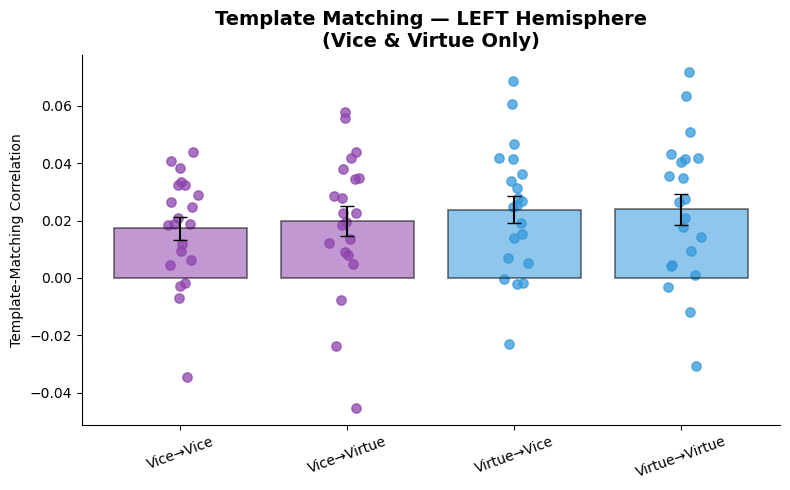

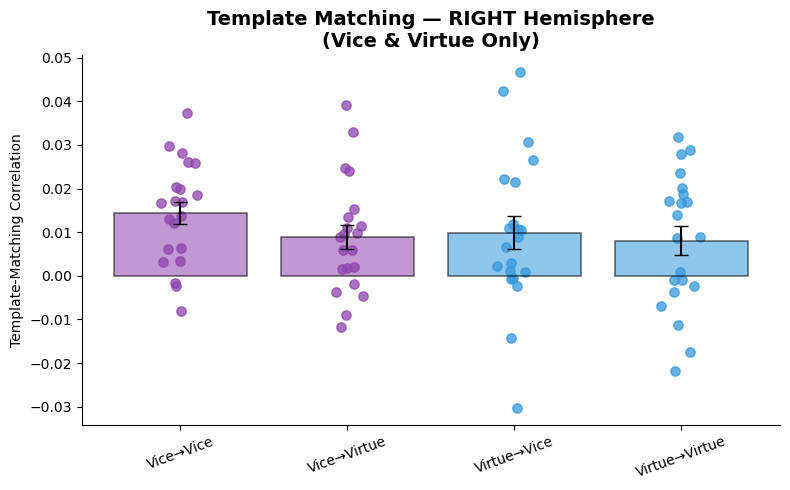

In [13]:
plot_condensed_4bar(results_left, "LEFT")
plot_condensed_4bar(results_right, "RIGHT")


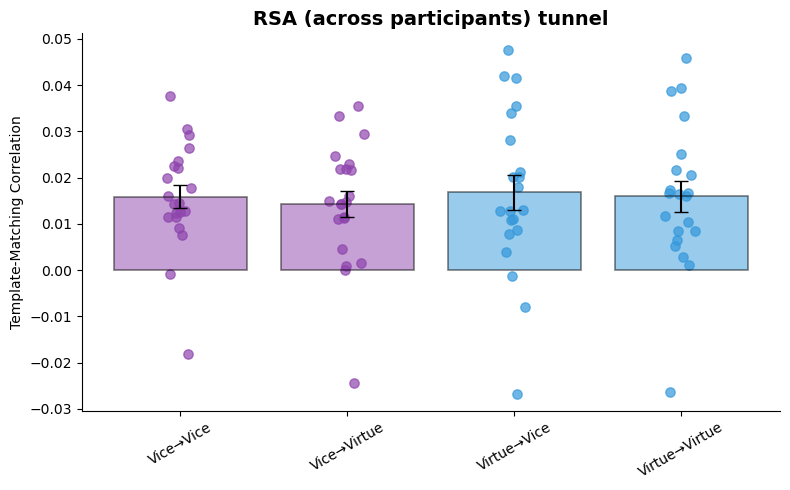

In [14]:

# ---------------------------------------------
# Compute participant-level averages across hemispheres
# ---------------------------------------------
results_avg = {}
for key in ["vice", "virtue"]:
    results_avg[key] = (results_left[key] + results_right[key]) / 2.0

# ---------------------------------------------
# Extract participant-level values for the 4 conditions
# ---------------------------------------------
VV  = results_avg["vice"][:, :, 0].mean(axis=0)    # Vice→Vice
VVu = results_avg["vice"][:, :, 1].mean(axis=0)    # Vice→Virtue
uV  = results_avg["virtue"][:, :, 0].mean(axis=0)  # Virtue→Vice
uVu = results_avg["virtue"][:, :, 1].mean(axis=0)  # Virtue→Virtue

participant_values = [VV, VVu, uV, uVu]

# ---------------------------------------------
# Compute means and SEMs
# ---------------------------------------------
means = [np.mean(vals) for vals in participant_values]
sems  = [np.std(vals)/np.sqrt(len(vals)) for vals in participant_values]

labels = ["Vice→Vice", "Vice→Virtue", "Virtue→Vice", "Virtue→Virtue"]
colors = ["#8E44AD", "#8E44AD", "#3498DB", "#3498DB"]  # color by event type

# ---------------------------------------------
# Plot
# ---------------------------------------------
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter participant-level dots
for i, vals in enumerate(participant_values):
    ax.scatter(
        np.ones(len(vals))*i + np.random.normal(0, 0.05, len(vals)),
        vals,
        color=colors[i],
        alpha=0.7,
        s=45
    )

# Bars with SEM
ax.bar(
    x, means, yerr=sems,
    color=colors, alpha=0.5,
    edgecolor="black", linewidth=1.2,
    capsize=5
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="center")
ax.set_ylabel("Template-Matching Correlation")
ax.set_title(f"RSA (across participants) {whichStory}", fontsize=14, weight="bold")
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(str(save_dir)+f'{whichROI}_{whichStory}_{whichVersion}_RSAacrossParticipants.png', dpi=300)  
plt.show()


In [15]:
# Participant-level values
ViceVice  = results_avg["vice"][:, :, 0].mean(axis=0)    # Vice→Vice VV
ViceVirtue = results_avg["vice"][:, :, 1].mean(axis=0)    # Vice→Virtue VVu
VirtueVice  = results_avg["virtue"][:, :, 0].mean(axis=0)  # Virtue→Vice uV
VirtueVirtue = results_avg["virtue"][:, :, 1].mean(axis=0)  # Virtue→Virtue uVu

# 1️⃣ Matching vs non-matching template for each event type
t1, p1 = ttest_rel(ViceVice, ViceVirtue)   # Vice events: Vice vs Virtue template
t2, p2 = ttest_rel(VirtueVirtue, VirtueVice)   # Virtue events: Virtue vs Vice template

print("=== Matching vs Non-matching Template ===")
print(f"Vice events: t={t1:.3f}, p={p1:.4f}")
print(f"Virtue events: t={t2:.3f}, p={p2:.4f}")

# 2️⃣ all 6 pairwise comparisons among 4 conditions
pairs = [("ViceVice","ViceVirtue"),("ViceVice","VirtueVice"),("ViceVice","VirtueVirtue"),("ViceVirtue","VirtueVice"),("ViceVirtue","VirtueVirtue"),("VirtueVice","VirtueVirtue")]
vals = {"ViceVice":ViceVice, "ViceVirtue":ViceVirtue, "VirtueVice":VirtueVice, "VirtueVirtue":VirtueVirtue}

print("\n=== All Pairwise Comparisons (Paired t-tests) ===")
for a,b in pairs:
    t,p = ttest_rel(vals[a], vals[b])
    print(f"{a} vs {b}: t={t:.3f}, p={p:.4f}")


=== Matching vs Non-matching Template ===
Vice events: t=1.017, p=0.3211
Virtue events: t=-0.500, p=0.6227

=== All Pairwise Comparisons (Paired t-tests) ===
ViceVice vs ViceVirtue: t=1.017, p=0.3211
ViceVice vs VirtueVice: t=-0.286, p=0.7775
ViceVice vs VirtueVirtue: t=-0.051, p=0.9600
ViceVirtue vs VirtueVice: t=-0.646, p=0.5257
ViceVirtue vs VirtueVirtue: t=-0.555, p=0.5849
VirtueVice vs VirtueVirtue: t=0.500, p=0.6227


In [16]:
# -------------------------
# 1️⃣ Participant-level values table
# -------------------------
df_values = pd.DataFrame({
    "ViceVice": ViceVice,
    "ViceVirtue": ViceVirtue,
    "VirtueVice": VirtueVice,
    "VirtueVirtue": VirtueVirtue
})

df_values.to_csv(str(save_dir)+f"{whichROI}_{whichStory}_{whichVersion}_participant_values.csv", index=False)

# -------------------------
# 2️⃣ T-test results summary table
# -------------------------
rows = []

# Main comparison results
rows.append({"Comparison": "Vice: ViceVice vs ViceVirtue", "t": t1, "p": p1})
rows.append({"Comparison": "Virtue: VirtueVirtue vs VirtueVice", "t": t2, "p": p2})

# All 6 pairwise comparisons
for a, b in pairs:
    t, p = ttest_rel(vals[a], vals[b])
    rows.append({"Comparison": f"{a} vs {b}", "t": t, "p": p})

df_tests = pd.DataFrame(rows)
df_tests.to_csv(str(save_dir)+f"{whichROI}_{whichStory}_{whichVersion}_ttest_results.csv", index=False)



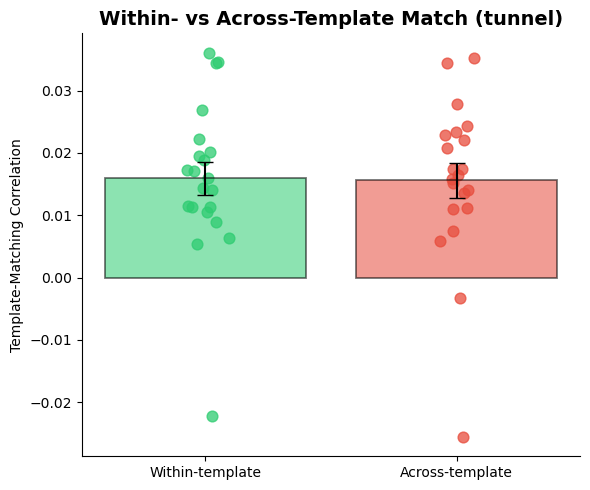

   Within- vs Across-Template Statistics   
Paired t-test: t(20) = 0.401, p = 0.69279
Cohen's dz: 0.087

          One-sample t-tests vs 0          
Within-template:  t(20) = 5.858, p = 0.00001
Across-template: t(20) = 5.466, p = 0.00002


In [17]:
# ======================================================
# 2-Bar Collapsed Plot: Within-template vs Across-template
# ======================================================

# Participant-level collapsed values
within = (VV + uVu) / 2      # template matches event
across = (VVu + uV) / 2      # template does NOT match event

collapsed_vals = [within, across]
collapsed_labels = ["Within-template", "Across-template"]
collapsed_colors = ["#2ECC71", "#E74C3C"]

# Means and SEMs
collapsed_means = [np.mean(v) for v in collapsed_vals]
collapsed_sems  = [np.std(v)/np.sqrt(len(v)) for v in collapsed_vals]

# ---------------------------------------------
# Plot
# ---------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(2)

# Scatter participant dots
for i, vals in enumerate(collapsed_vals):
    ax.scatter(
        np.ones(len(vals)) * i + np.random.normal(0, 0.04, len(vals)),
        vals,
        color=collapsed_colors[i],
        s=60,
        alpha=0.75
    )

# Bars
ax.bar(
    x, collapsed_means, yerr=collapsed_sems,
    color=collapsed_colors,
    alpha=0.55,
    edgecolor="black",
    linewidth=1.3,
    capsize=6
)

# Styling
ax.set_xticks(x)
ax.set_xticklabels(collapsed_labels)
ax.set_ylabel("Template-Matching Correlation")
ax.set_title(f"Within- vs Across-Template Match ({whichStory})", fontsize=14, weight="bold")
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(str(save_dir)+f"{whichROI}_{whichStory}_{whichVersion}_2bar_withinAcross.png", dpi=300)
plt.show()

# ======================================================
# Stats: Paired t-test and Effect Size (Cohen's dz)
# ======================================================

# Paired t-test
t_stat, p_val = ttest_rel(within, across)

# Effect size: Cohen's dz for paired samples
diff = within - across
cohens_dz = np.mean(diff) / np.std(diff, ddof=1)

print("===========================================")
print("   Within- vs Across-Template Statistics   ")
print("===========================================")
print(f"Paired t-test: t({len(within)-1}) = {t_stat:.3f}, p = {p_val:.5f}")
print(f"Cohen's dz: {cohens_dz:.3f}")

# ======================================================
# One-sample t-tests (within-template and across-template vs zero)
# ======================================================

t_within, p_within = ttest_1samp(within, 0)
t_across, p_across = ttest_1samp(across, 0)

print("\n===========================================")
print("          One-sample t-tests vs 0          ")
print("===========================================")
print(f"Within-template:  t({len(within)-1}) = {t_within:.3f}, p = {p_within:.5f}")
print(f"Across-template: t({len(across)-1}) = {t_across:.3f}, p = {p_across:.5f}")

